In [1]:
import os
# os.chdir("")

from tqdm import tqdm
import subprocess
import os
from pathlib import Path
import sys
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


In [2]:
root = Path("C:/Users/serr_da/Documents/Datasets/flair_1_toy_dataset")
image_dir = root / "flair_1_toy_aerial_train_NDVI"
mask_dir = root / "flair_1_toy_labels_train_remap"

# Load intersected paths 
image_paths = [str(p) for p in sorted(image_dir.rglob("*.tif"))]
mask_paths = [str(p) for p in sorted(mask_dir.rglob("*.tif"))]

print(len(image_paths))
print(len(mask_paths))

200
200


In [3]:
image_list = []
for path in image_paths[:20]:
    with rasterio.open(path) as src:
        img = src.read()
        img = img.transpose(1, 2, 0)  # (H, W, C)
        img = img / 255.0

        image_list.append(img)

In [4]:
mask_list = []
for path in mask_paths[:20]:
    with rasterio.open(path) as src:
        msk = src.read().squeeze()  # (H, W)
       
        mask_list.append(msk)

In [21]:
image_list[0].shape

(512, 512, 6)

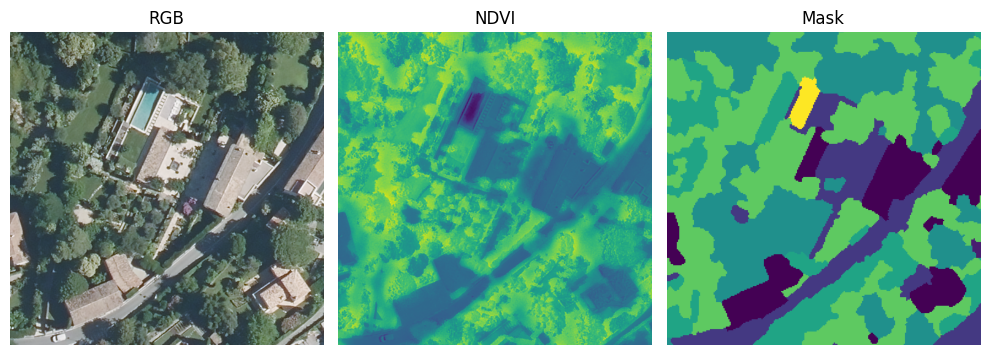

In [35]:
idx = 5
fig, axes = plt.subplots(1, 3, figsize=(10, 5))  # 1 row, 2 columns

# Plot first image
axes[0].imshow(image_list[idx][..., :3])  # use cmap='gray' if single channel
axes[0].set_title("RGB")
axes[0].axis('off')

# Plot second image
axes[1].imshow(image_list[idx][..., 5])
axes[1].set_title("NDVI")
axes[1].axis('off')

axes[2].imshow(mask_list[idx])
axes[2].set_title("Mask")
axes[2].axis('off')

plt.tight_layout()
plt.show()